# Notebook pour charger le jeu sur VS Code

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/prog_IceHockey

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/prog_IceHockey


In [ ]:
import os
import torch
device = 'GPU' if torch.cuda.is_available() else 'CPU'
print('Vous utilisez le {} '.format(device))

Vous utilisez le GPU 


In [ ]:
import gymnasium as gym
import ale_py

print(f"Version de ALE: {ale_py.__version__}")

game_list = [spec for spec in gym.registry.keys() if 'IceHockey' in spec]
print(f"Jeux d'arcade disponibles: {game_list}")

Version de ALE: 0.11.2
Jeux d'arcade disponibles: ['IceHockey-v0', 'IceHockey-v4', 'IceHockeyNoFrameskip-v0', 'IceHockeyNoFrameskip-v4', 'ALE/IceHockey-v5']


In [ ]:
%pip install -r requirements.txt

In [ ]:
! AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms
	/usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.


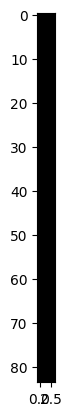

Forme finale de l'observation : (84, 84, 4)


In [ ]:
import supersuit as ss
import matplotlib.pyplot as plt
from pettingzoo.atari import ice_hockey_v2

def get_env():
    # 1. Env de base
    env = ice_hockey_v2.env(render_mode="rgb_array")

    # 2. Réduction à 1 seul canal (Rouge) -> (210, 160, 1)
    env = ss.color_reduction_v0(env, mode='R')

    # 3. Redimensionnement -> (84, 84, 1)
    env = ss.resize_v1(env, x_size=84, y_size=84)

    # 4. On empile 4 images -> (84, 336, 1) ou (1, 84, 336) selon ta version
    env = ss.frame_stack_v1(env, 4)

    # 5. On convertit en float32
    env = ss.dtype_v0(env, 'float32')

    return env
# --- TEST DE VÉRIFICATION ---
env = get_env()
env.reset()
obs, reward, term, trunc, info = env.last()
plt.imshow(obs[0], cmap='gray')
plt.show()
print(f"Forme finale de l'observation : {obs.shape}")

In [ ]:
import torch
import numpy as np
from pettingzoo.atari import ice_hockey_v2
from MAPOCA.actor import MultiAgentActors


# 1. Utilise ta fonction get_env() pour avoir les wrappers SuperSuit
env = get_env()
# Note : Si tu veux voir le jeu, change render_mode="human" dans get_env
# ou utilise render_mode="rgb_array" pour Colab.

env.reset()

max_steps = 8000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

actor = MultiAgentActors(action_dim=18).to(device)

# On suppose que 'actor' est déjà initialisé et envoyé sur le device
actor.eval() # Mode évaluation

for i, agent in enumerate(env.agent_iter()):
    observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        action = None
    else:
        # --- AJUSTEMENT DES DIMENSIONS ---
        # observation est (84, 84, 4) -> on veut (4, 84, 84)
        obs_input = observation.transpose(2, 0, 1)

        # Conversion en tenseur [1, 4, 84, 84]
        obs_tensor = torch.from_numpy(obs_input).float().unsqueeze(0).to(device)
        obs_tensor = obs_tensor/255.0
        with torch.no_grad():
            # Utilise get_action pour avoir une décision (déterministe pour la démo)
            action = actor.get_action(obs_tensor, deterministic=True).item()

    env.step(action)

    if i >= max_steps:
        print(f"Arrêt manuel après {max_steps} itérations.")
        break

env.close()
print("Démo terminée proprement !")

Arrêt manuel après 8000 itérations.
Démo terminée proprement !


Démarrage de la capture vidéo...
✅ Vidéo sauvegardée avec succès : demo_hockey.gif


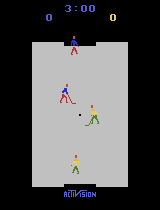

In [ ]:
import PIL.Image
from IPython.display import display

import PIL.Image
from IPython.display import Image, display
import torch

# --- DÉFINITION ---
def record_video(env, actor, filename="demo_hockey.gif", device="cpu"):
    print("Démarrage de la capture vidéo...")
    env.reset()
    frames = []

    # On passe l'actor en mode évaluation
    actor.eval()

    for i, agent in enumerate(env.agent_iter()):
        obs, reward, terminated, truncated, info = env.last()

        # Capture du rendu AVANT de passer à l'étape suivante
        if i % 2 == 0:
            frame = env.render()
            if frame is not None:
                frames.append(PIL.Image.fromarray(frame))

        if terminated or truncated:
            action = None
        else:
            # Prétraitement (H, W, C) -> (C, H, W)
            obs_input = obs.transpose(2, 0, 1)
            obs_tensor = torch.from_numpy(obs_input).float().unsqueeze(0).to(device)

            with torch.no_grad():
                action = actor.get_action(obs_tensor, deterministic=True).item()

        env.step(action)

        if terminated or truncated or i > 1500: # Limite pour éviter un GIF trop lourd
            break

    if len(frames) > 0:
        # --- SAUVEGARDE ---
        frames[0].save(filename, save_all=True, append_images=frames[1:], duration=40, loop=0)
        print(f"✅ Vidéo sauvegardée avec succès : {filename}")
    else:
        print("❌ Erreur : Aucune frame n'a été capturée.")

# --- EXÉCUTION (L'appel manquant) ---
# Assure-toi que ton 'actor' et ton 'env' sont bien initialisés avant
record_video(env, actor, filename="demo_hockey.gif", device=device)

# --- VISUALISATION ---
display(Image(filename="demo_hockey.gif"))




In [ ]:
ls

checkpoints_hockey/  download_game.ipynb  MAPOCA/    requirements.txt
demo_hockey.gif      evolution_poca.gif   README.md  VDN/


# Exécution de MA-POCA

In [ ]:
# importation des bibliothèques et des classes nécessaires

from MAPOCA.multi_agent_buffer import MultiAgentBuffer

buffer = MultiAgentBuffer()


Première version de collect_trajectories avec la récompense caclulée grâce à la mémoire RAM

In [ ]:
def collect_trajectories(env, actor, buffer, alpha, max_steps):
    env.reset()

    # --- INITIALISATION  ---
    temp_obs = {}
    temp_acts = {}
    temp_logprobs = {}
    temp_rewards = {}

    step_count = 0

    for agent in env.agent_iter():
        obs, reward, terminated, truncated, _ = env.last()
        ram = env.unwrapped.ale.getRAM()

        # Positions RAM
        x_goal_adv, y_goal_adv = 155, 105
        x_goal_adv, y_goal_adv = float(x_goal_adv), float(y_goal_adv)
        x_puck, y_puck = ram[54], ram[55]
        x_puck, y_puck = float(x_puck), float(y_puck)

        # position de tous les agents

        pos_agent1 = np.array([ram[56], ram[57]])
        pos_agent2 = np.array([ram[58], ram[59]])
        pos_adv1 = np.array([ram[60], ram[61]])
        pos_adv2 = np.array([ram[62], ram[63]])


        if agent == "first_0":
            x_j, y_j = ram[56], ram[57]
            x_j, y_j = float(x_j), float(y_j)
        else:
            x_j, y_j = ram[58], ram[59]
            x_j, y_j = float(x_j), float(y_j)


        # Calcul des rewards
        dist = np.sqrt((x_j - x_puck)**2 + (y_j - y_puck)**2)
        dist_puck_global = np.sqrt((x_puck - x_goal_adv)**2 + (y_puck - y_goal_adv)**2)

        # distance entre les joueurs (de la même équipe)
        p1, p2 = pos_agent1.astype(float), pos_agent2.astype(float)
        dist_coequipier = np.linalg.norm(p1 - p2)

        # pénalité de collision

        collision_penalty = 0
        if dist_coequipier < 10: # Seuil de contact
            collision_penalty = -0.5

        # bonus d'évitement
        pos_adv1, pos_adv2 = pos_adv1.astype(float), pos_adv2.astype(float)
        dist_to_adv1 = np.linalg.norm(np.array([x_j, y_j]) - pos_adv1)
        dist_to_adv2 = np.linalg.norm(np.array([x_j, y_j]) - pos_adv2)
        dist_adv_plus_proche = min(dist_to_adv1, dist_to_adv2)

        goal_proximity_reward = 1.0 / (dist_puck_global + 1.0)
        distance_reward = 1.0 / (dist + 1.0)

        alignment_bonus = 2 if x_j < x_puck else -1
        hit_reward = reward * 50
        time_penalty = -0.5
        defense_penalty = -1 if x_puck < 30 else 0


        offensive_reward = 0
        if x_puck > 110:
            offensive_reward += 5
            if dist <= 15:
                offensive_reward += 5

        # --- RECOMPENSE PROPRE À L'AGENT ---
        current_agent_reward = hit_reward + \
                               alpha * (distance_reward * 15) + \
                               (goal_proximity_reward * 15) + \
                               alignment_bonus + \
                               offensive_reward + \
                               time_penalty + \
                               defense_penalty + \
                               collision_penalty

        temp_rewards[agent] = current_agent_reward

        done = terminated or truncated

        # Logique Actor
        if done:
            action, logp = None, 0
        else:
            obs_permu = obs.transpose(2, 0, 1)
            obs_tensor = torch.from_numpy(obs_permu).float().unsqueeze(0).to(device)
            with torch.no_grad():
                logits = actor(obs_tensor)
                dist_prob = torch.distributions.Categorical(logits=logits)
                action_tensor = dist_prob.sample()
                logp = dist_prob.log_prob(action_tensor).item()
                action = action_tensor.item()

        env.step(action)

        temp_obs[agent] = obs
        if action is not None:
            temp_acts[agent] = action
            temp_logprobs[agent] = logp

        # --- SYNCHRONISATION ET STOCKAGE ---
        if len(temp_acts) == 2:
            # Correction de l'indentation ici
            buffer.add(
                observation=[temp_obs['first_0'], temp_obs['second_0']],
                action=[temp_acts['first_0'], temp_acts['second_0']],
                logprob=[temp_logprobs['first_0'], temp_logprobs['second_0']],
                reward=[temp_rewards['first_0'], temp_rewards['second_0']], # Séparées !
                done=done
            )

            temp_acts, temp_logprobs = {}, {} # Reset pour le pas t+1
            step_count += 1

        if done or step_count >= max_steps:
            break

    return step_count

In [ ]:
def compute_returns_lambda(rewards, values, next_value, dones, gamma=0.99, lmbda = 0.95):
    "Calcule G_t^(lambda) pour un agent"

    returns = torch.zeros_like(rewards)
    gae = 0

    for t in reversed(range(len(rewards))):
        if t == len(rewards) -1:
            next_non_terminal = 1.0 - dones[t]
            next_val = next_value
        else:
            next_non_terminal = 1.0 - dones[t+1]
            next_val = values[t+1]

        # TD Error (delta)
        delta = rewards[t] + gamma * next_val * next_non_terminal - values[t]

        # GAE (Generalized Advantage Estimation) qui est équivalent au TD(lambda)
        gae = delta + gamma * lmbda * next_non_terminal * gae

        returns[t] = gae + values[t]

    return returns


In [ ]:
def prepare_targets(buffer, critic, gamma=0.99, lmbda = 0.95):
    obs_ag1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
    obs_ag2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()

    rewards = torch.tensor(buffer.rewards).float()  # Shape: (N, 2)
    dones = torch.tensor(buffer.dones).float()      # Shape: (N,)

    #2. ici on cherche à obtenir les valeurs V du critic centralisé

    with torch.no_grad():
        values = critic([obs_ag1, obs_ag2])  # Shape: (N, 2)

        next_value = torch.zeros(2)

    all_returns = []
    all_advantages = []
    for i in range(2):
        ret = compute_returns_lambda(
            rewards[:, i], values[:, i], next_value[i], dones, gamma, lmbda
        )
        advantage = ret - values[:, i]
        all_returns.append(ret)
        all_advantages.append(advantage)


    return torch.stack(all_returns, dim=1), torch.stack(all_advantages, dim=1)

In [ ]:
def update_mapoca(actor, critic, buffer, optimizer_actor, optimizer_critic):
    #1. Préparation des données

    returns, advantages = prepare_targets(buffer, critic, gamma=0.99, lmbda = 0.95)

    #2. on applatit ensuite les dimensions pour le calcul de la perte

    obs_ag1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
    obs_ag2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()
    actions = torch.tensor(buffer.actions)  # Shape: (N, 2)
    old_logprobs = torch.tensor(buffer.logprobs)  # Shape: (N, 2)

    #3. Mise à jour du critic centralisé

    current_values = critic([obs_ag1, obs_ag2])  # Shape: (N, 2)
    critic_loss = torch.nn.MSELoss()(current_values, returns)

    # 4. Mise à jour de l'actor

    # pour l'agent 1
    logits1 = actor(obs_ag1)  # Shape: (N, action_dim)
    dist1 = torch.distributions.Categorical(logits=logits1)
    new_logprob1 = dist1.log_prob(actions[:, 0])  # Log-prob de l'action prise par agent 1

    # pour l'agent 2

    logits2 = actor(obs_ag2)  # Shape: (N, action_dim)
    dist2 = torch.distributions.Categorical(logits=logits2)
    new_logprob2 = dist2.log_prob(actions[:, 1])  # Log-prob de l'action prise par agent 2

    # Calcul de la perte Policy Gradient pour les deux agents

    actor_loss = -(new_logprob1 * advantages[:, 0]).mean() - (new_logprob2 * advantages[:, 1]).mean()

    # Ajout de l'entropie pour encourager l'exploration

    entropy = dist1.entropy().mean() + dist2.entropy().mean()
    total_actor_loss = actor_loss - 0.05 * entropy

    optimizer_actor.zero_grad()
    total_actor_loss.backward()
    optimizer_actor.step()

    return critic_loss.item(), actor_loss.item()



On vérifie ce que les joueurs font

## Exécution de la boucle principale

📦 Dernier checkpoint détecté : /content/drive/MyDrive/prog_IceHockey/checkpoints_hockey/checkpoint_ep_8500.pth
🚀 Reprise confirmée à partir de l'épisode 8501


  0%|          | 0/2499 [00:00<?, ?it/s]

0.5
DEBUG: Forme du tenseur rewards : torch.Size([177, 2])
DEBUG: Exemple de récompenses (Step 0) : Agent 1=1.80, Agent 2=-1.16


  0%|          | 1/2499 [00:01<1:06:41,  1.60s/it]

0.5


...

0.5


100%|█████████▉| 2498/2499 [49:23<00:01,  1.16s/it]

0.5


100%|██████████| 2499/2499 [49:24<00:00,  1.19s/it]


Checkpoint sauvegardé à l'épisode 10999


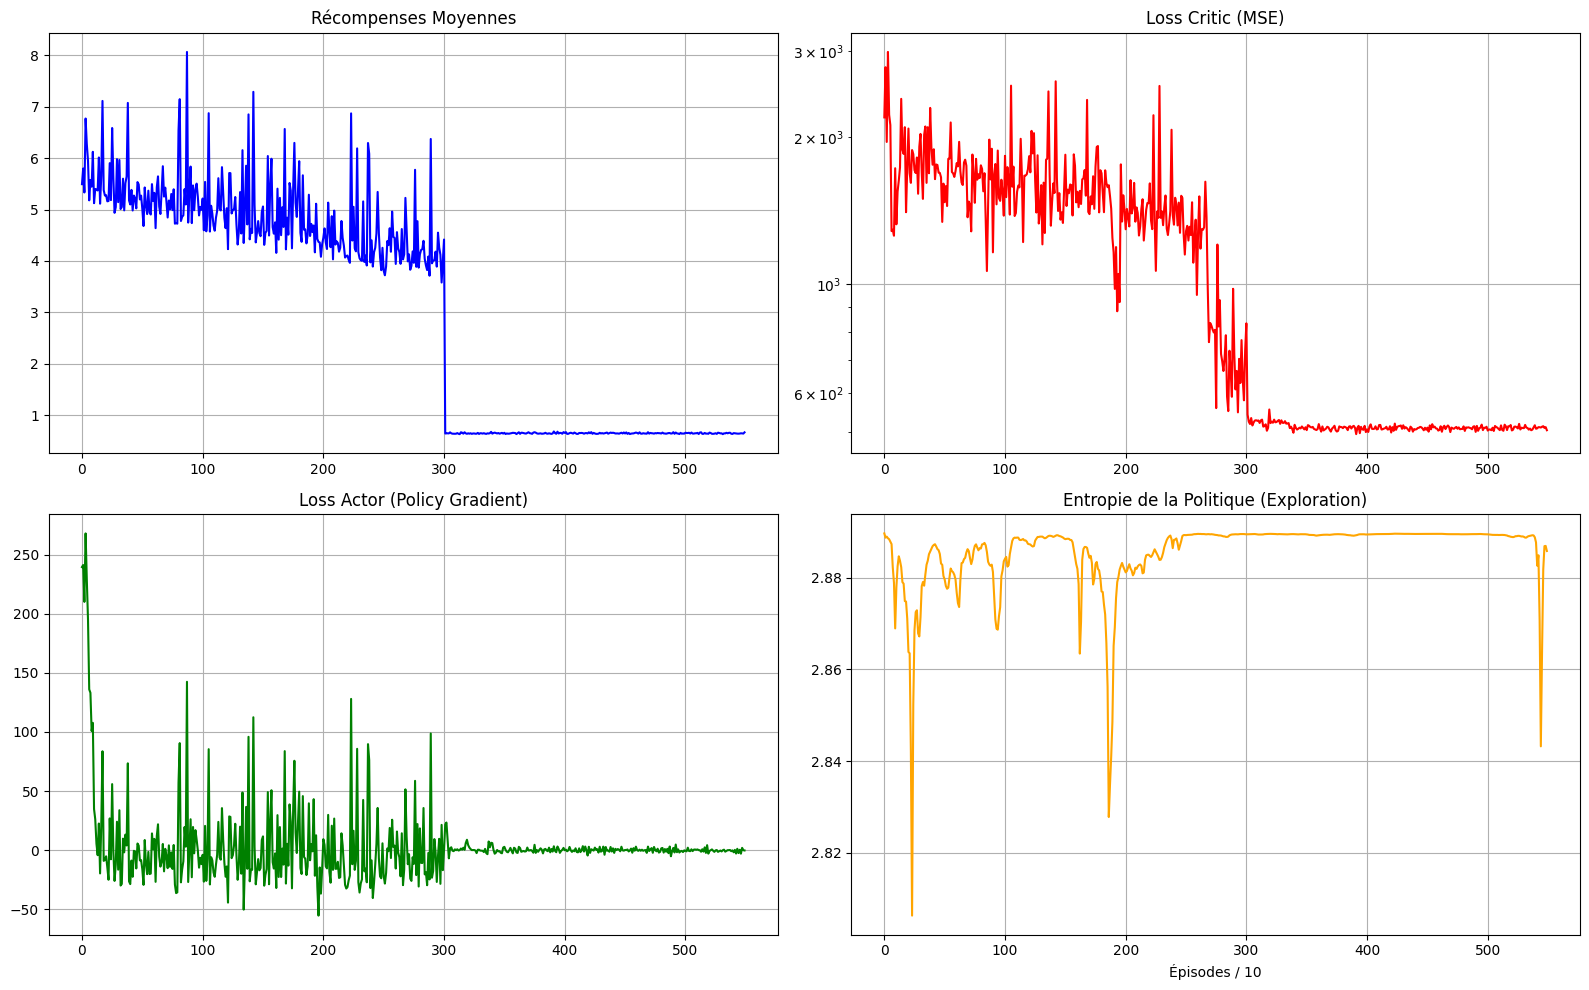

In [ ]:
#importation des bibliothèques

import os
import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob
import re

# importation des modules

from MAPOCA.multi_agent_buffer import MultiAgentBuffer
from MAPOCA.centralized_critic import Centralized_critic
from MAPOCA.actor import MultiAgentActors
from MAPOCA.observation_encoding import Impala_CNN, Impala_Layer
from MAPOCA.RSA import RSAModule

# on créé un dossier pour les sauvegardes du modèle
checkpoint_dir = '/content/drive/MyDrive/prog_IceHockey/checkpoints_hockey'
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = '/content/drive/MyDrive/prog_IceHockey/checkpoints_hockey/model_ep_8500.pth'
files = glob.glob(os.path.join(checkpoint_dir, "*.pth"))

# Hyperparamètres
LR_ACTOR = 1e-4
LR_CRITIC = 3e-4
START_ALPHA= 1.0
END_ALPHA = 0.5
GAMMA = 0.99
LMBDA = 0.95
BATCH_SIZE = 128  # Nombre de pas de temps par mise à jour
DECAY_EPISODES = 3000
TOTAL_EPISODES = 11000

actor = MultiAgentActors(action_dim = 18).to(device)
critic = Centralized_critic(num_agents=2).to(device)

optimizer_actor = optim.Adam(actor.parameters(), lr=LR_ACTOR)
optimizer_critic = optim.Adam(critic.parameters(), lr=LR_CRITIC)

last_checkpoint = None
start_episode = 0

if files:
    # 2. Trouver le fichier avec le numéro d'épisode le plus élevé
    # On extrait les nombres des noms de fichiers pour trier
    def extract_epoch(filename):
        nums = re.findall(r'\d+', filename)
        return int(nums[-1]) if nums else 0

    last_checkpoint = max(files, key=extract_epoch)

    print(f"Dernier checkpoint détecté : {last_checkpoint}")

    start_episode = extract_epoch(last_checkpoint) + 1

    # 3. Chargement (avec le map_location de sécurité)
    checkpoint = torch.load(last_checkpoint, map_location=device)

    actor.load_state_dict(checkpoint['actor_state_dict'])
    critic.load_state_dict(checkpoint['critic_state_dict'])
    optimizer_actor.load_state_dict(checkpoint['optimizer_actor_state_dict'])
    optimizer_critic.load_state_dict(checkpoint['optimizer_critic_state_dict'])
    actor_loss_history = checkpoint.get('actor_loss_history', [])
    entropy_history = checkpoint.get('entropy_history', [])

    # Récupération des historiques (si présents)

    rewards_history = checkpoint.get('rewards_history', [])
    critic_losses_history = checkpoint.get('critic_losses_history', [])

    print(f"Reprise confirmée à partir de l'épisode {start_episode}")
else:
    print("Aucun checkpoint trouvé. Démarrage d'un nouvel entraînement.")
    rewards_history = []
    critic_losses_history = []
    buffer = MultiAgentBuffer()

# Boucle principale

EPISODES_A_COURIR = TOTAL_EPISODES - start_episode
for i in tqdm(range(EPISODES_A_COURIR)):
    current_episode = start_episode + i
    alpha = max(END_ALPHA, START_ALPHA - (START_ALPHA - END_ALPHA) * (current_episode / DECAY_EPISODES))
    print(alpha)
    # On modifie collect_trajectories pour qu'elle retourne aussi la distance moyenne
    step_count = collect_trajectories(env, actor, buffer, alpha=alpha, max_steps=BATCH_SIZE)
    if len(buffer.observations) >= BATCH_SIZE:
        # 1. Préparation des tenseurs (permute inclus)
        obs_raw_1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
        obs_raw_2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()
        obs_ag1 = obs_raw_1.permute(0, 3, 1, 2).to(device)
        obs_ag2 = obs_raw_2.permute(0, 3, 1, 2).to(device)

        rewards = torch.tensor(buffer.rewards).float().to(device)
        dones = torch.tensor(buffer.dones).float().to(device)
        actions = torch.tensor(buffer.actions).to(device)

        if i ==0:
          print(f"DEBUG: Forme du tenseur rewards : {rewards.shape}")
          print(f"DEBUG: Exemple de récompenses (Step 0) : Agent 1={rewards[0,0]:.2f}, Agent 2={rewards[0,1]:.2f}")

        # 2. Calcul des Valeurs et Retours
        with torch.no_grad():
            values = critic([obs_ag1, obs_ag2]) # (Batch, 2)
            next_value = torch.zeros(2).to(device)


            all_returns = []
            for i in range(2):
                ret = compute_returns_lambda(rewards[:, i], values[:, i], next_value[i], dones, GAMMA, LMBDA)
                all_returns.append(ret)

            returns = torch.stack(all_returns, dim=1)
            # Important : Advantage se calcule avec les valeurs détachées du gradient
            advantages = returns - values

        # 3. Mise à jour du Critic
        current_values = critic([obs_ag1, obs_ag2])
        critic_loss = F.mse_loss(current_values, returns)
        optimizer_critic.zero_grad()
        critic_loss.backward()
        optimizer_critic.step()

        # 4. Mise à jour de l'Actor
        dist1 = torch.distributions.Categorical(logits=actor(obs_ag1))
        logp1 = dist1.log_prob(actions[:, 0])
        ent1 = dist1.entropy().mean() # Entropie Agent 1

        dist2 = torch.distributions.Categorical(logits=actor(obs_ag2))
        logp2 = dist2.log_prob(actions[:, 1])
        ent2 = dist2.entropy().mean() # Entropie Agent 2

        # MA-POCA Loss (on utilise les avantages calculés par le critique centralisé)
        actor_loss = -(logp1 * advantages[:, 0]).mean() - (logp2 * advantages[:, 1]).mean()

        # moyenne de l'entropie des deux agents

        avg_entropy = (ent1 + ent2) / 2


        optimizer_actor.zero_grad()
        actor_loss.backward()
        optimizer_actor.step()

        # Affichage (Somme des rewards sur le batch / nombre d'agents)
        avg_reward = rewards.sum().item() / BATCH_SIZE
        if current_episode % 10 == 0:
            rewards_history.append(avg_reward)
            critic_losses_history.append(critic_loss.item())
            actor_loss_history.append(actor_loss.item())
            entropy_history.append(avg_entropy.item())
            print(f" Episode {current_episode} | Score Moyen: {avg_reward:.4f} | Loss Critic: {critic_loss.item():.4e}")

        if current_episode % 100 == 0:
            print(f"Épisode {current_episode} | Alpha actuel: {alpha:.2f}")

        if current_episode % 500 == 0:
            checkpoint = {
                'episode': current_episode, # On sauve l'épisode RÉEL
                'actor_state_dict': actor.state_dict(),
                'critic_state_dict': critic.state_dict(),
                'optimizer_actor_state_dict': optimizer_actor.state_dict(),
                'optimizer_critic_state_dict': optimizer_critic.state_dict(),
                'rewards_history': rewards_history,
                'entropy_history': entropy_history,
                'critic_losses_history': critic_losses_history,
                'actor_loss_history': actor_loss_history,
                'alpha': alpha
            }
            torch.save(checkpoint, checkpoint_path)
            torch.save(checkpoint, os.path.join(checkpoint_dir, f'model_ep_{current_episode}.pth'))

        buffer.clear()

print(f"Checkpoint sauvegardé à l'épisode {current_episode}")


# 5. Visualisation double
plt.figure(figsize=(16, 10))

# 1. Récompenses
plt.subplot(2, 2, 1)
plt.plot(rewards_history, color='blue')
plt.title("Récompenses Moyennes")
plt.grid(True)

# 2. Loss Critic
plt.subplot(2, 2, 2)
plt.plot(critic_losses_history, color='red')
plt.yscale('log')
plt.title("Loss Critic (MSE)")
plt.grid(True)

# 3. Loss Actor
plt.subplot(2, 2, 3)
plt.plot(actor_loss_history, color='green')
plt.title("Loss Actor (Policy Gradient)")
plt.grid(True)

# 4. Entropie
plt.subplot(2, 2, 4)
plt.plot(entropy_history, color='orange')
plt.title("Entropie de la Politique (Exploration)")
plt.xlabel("Épisodes / 10")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
load_checkpoint = True
checkpoint_path = '/content/drive/MyDrive/checkpoints_hockey/checkpoint_ep_3000.pth'

if load_checkpoint and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    actor.load_state_dict(checkpoint['actor_state_dict'])
    critic.load_state_dict(checkpoint['critic_state_dict'])
    optimizer_actor.load_state_dict(checkpoint['optimizer_actor_state_dict'])
    optimizer_critic.load_state_dict(checkpoint['optimizer_critic_state_dict'])
    start_episode = checkpoint['episode']
    rewards_history = checkpoint['rewards_history']
    print(f" Reprise de l'entraînement à l'épisode {start_episode}")
else:
    start_episode = 0

A exécuter après avoir exécuté le bloc de la boucle principale. Le bloc suivant permet de voir comment les joueurs se comportent après exécution de MA-POCA

Modèle de l'évaluation chargé avec succès
Démarrage de la capture vidéo...
✅ Vidéo sauvegardée avec succès : match_ep_10500.gif


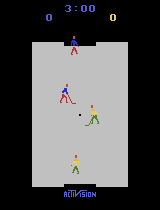

In [ ]:
path_10500 = '/content/drive/MyDrive/prog_IceHockey/checkpoints_hockey/model_ep_10500.pth'

if os.path.exists(path_10500):
    checkpoint = torch.load(path_10500, map_location=device)

    actor.load_state_dict(checkpoint['actor_state_dict'])


    # Très important pour le CPU : passer le modèle en mode évaluation
    actor.to(device)
    actor.eval()

    print(f"Modèle de l'évaluation chargé avec succès")


    # on lance la vidéo
    record_video(env, actor, filename="match_ep_10500.gif", device=device)

    # 4. Affichage
    from IPython.display import Image, display
    display(Image(filename="match_ep_10500.gif"))
else:
    print("❌ Erreur : Checkpoint introuvable. Vérifie le chemin.")


Démarrage de la capture vidéo...
✅ Vidéo sauvegardée avec succès : demo__debug_hockey.gif


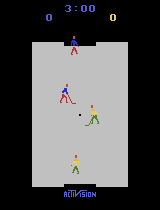

In [ ]:
import PIL.Image
from IPython.display import display

import PIL.Image
from IPython.display import Image, display

# Test avec des actions aléatoires au lieu de ton modèle
env.reset()
for agent in env.agent_iter():
    obs, reward, terminated, truncated, _ = env.last()
    if terminated or truncated:
        action = None
    else:
        action = env.action_space(agent).sample() # Action au hasard
    env.step(action)
    # Regarde si là, les joueurs bleus se déplacent dans tous les sens
record_video(env, actor, filename="demo__debug_hockey.gif", device=device)

display(Image(filename="demo__debug_hockey.gif"))